# CreditIQ - Full Credit Score Analysis Notebook
> **Pipeline:** EDA - Preprocessing (Linearisation · Normalisation · Re-binning) -
> Feature Engineering - RFECV - SMOTE - Optuna Tuning -
> 9 Base Models - Voting Ensemble - Stacking - Full Evaluation - SHAP

**Install dependencies once:**
```bash
pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm shap optuna imbalanced-learn scipy
```


## 0. Imports & Setup

In [1]:
#pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm shap optuna imbalanced-learn

In [ ]:
import warnings, math, io
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import (LabelEncoder, StandardScaler, MinMaxScaler,
                                    RobustScaler, label_binarize)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFECV, SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import optuna
import shap
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED        = 42
np.random.seed(SEED)
CLASS_NAMES = ["Poor", "Standard", "Good"]
LABEL_MAP   = {0: "Poor", 1: "Standard", 2: "Good"}
COLORS      = ["#ef4444", "#f59e0b", "#22c55e"]
LOG_FEATURES = ["Annual_Income", "Monthly_Inhand_Salary", "Outstanding_Debt",
                "Total_EMI_per_month", "Amount_invested_monthly"]
CAT_COLS    = ["Occupation", "Credit_Mix", "Payment_of_Min_Amount",
               "Age_Group", "Income_Bracket", "Delay_Bucket"]

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
print("All libraries loaded.")


✅ All libraries loaded.


## 1. Data Loading
**Option A** - Synthetic (runs immediately) | **Option B** - [Kaggle dataset](https://www.kaggle.com/datasets/parisrohan/credit-score-classification)


In [ ]:
# OPTION B: uncomment after placing train.csv in the same folder
# df_raw = pd.read_csv("train.csv")
# df_raw["Credit_Score"] = df_raw["Credit_Score"].map({"Poor":0,"Standard":1,"Good":2})

# OPTION A: Synthetic dataset (default - runs immediately)
def generate_dataset(n=10_000, seed=42):
    rng = np.random.default_rng(seed)
    ai  = rng.lognormal(10.8, 0.6, n).round(2)
    od  = rng.uniform(0, 4998, n).round(2)
    dfd = rng.integers(0, 62, n).astype(float)
    ndp = rng.integers(0, 22, n).astype(float)
    cha = rng.uniform(0, 35, n).round(1)
    cm  = rng.choice(["Bad","Standard","Good"], n, p=[0.3,0.4,0.3])
    cu  = rng.uniform(20, 50, n).round(2)
    nba = rng.integers(1, 10, n).astype(float)
    ncc = rng.integers(0, 12, n).astype(float)
    for arr in [ai, od, dfd, ndp, nba]:
        arr[rng.random(n) < 0.05] = np.nan
    s = (0.25*(ai/np.nanmax(ai))
        +0.20*(1-np.where(np.isnan(od),0.5,od)/4998)
        +0.15*(1-np.where(np.isnan(dfd),0.5,dfd)/62)
        +0.12*(cha/35)
        +0.10*(1-np.where(np.isnan(ndp),0.5,ndp)/22)
        +0.08*np.where(cm=="Good",1.0,np.where(cm=="Standard",0.5,0.0))
        +0.05*(1-cu/50)+0.05*rng.uniform(0,1,n))
    labels = np.where(np.clip(s,0,1)<0.38,0,np.where(np.clip(s,0,1)<0.65,1,2))
    return __import__("pandas").DataFrame({
        "Age": rng.integers(18,75,n).astype(float),
        "Occupation": rng.choice(["Scientist","Teacher","Engineer","Entrepreneur",
            "Developer","Lawyer","Doctor","Journalist","Manager","Accountant",
            "Musician","Mechanic","Writer","Architect","Media_Manager"],n),
        "Annual_Income": ai, "Monthly_Inhand_Salary": ai/12,
        "Num_Bank_Accounts": nba, "Num_Credit_Card": ncc,
        "Interest_Rate": rng.uniform(1,34,n).round(2),
        "Num_of_Loan": rng.integers(0,9,n).astype(float),
        "Delay_from_due_date": dfd, "Num_of_Delayed_Payment": ndp,
        "Changed_Credit_Limit": rng.uniform(0,30,n).round(2),
        "Num_Credit_Inquiries": rng.integers(0,17,n).astype(float),
        "Credit_Mix": cm, "Outstanding_Debt": od,
        "Credit_Utilization_Ratio": cu, "Credit_History_Age": cha,
        "Payment_of_Min_Amount": rng.choice(["Yes","No","NM"],n,p=[0.4,0.4,0.2]),
        "Total_EMI_per_month": rng.lognormal(4.5,0.8,n).round(2),
        "Amount_invested_monthly": rng.lognormal(5.0,1.0,n).round(2),
        "Monthly_Balance": rng.uniform(0,2000,n).round(2),
        "Credit_Score": labels,
    })

df_raw = generate_dataset(n=10_000, seed=42)
print(f"Shape  : {df_raw.shape}")
print("Target :", dict(df_raw["Credit_Score"].map(LABEL_MAP).value_counts()))
df_raw.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,2
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,2
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,2
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,2
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,2


## 2. Exploratory Data Analysis

In [4]:
print("Data Types & Non-Null Counts")
df_raw.info()
print("\n Descriptive Statistics")
df_raw.describe().round(2)


Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan    

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month,Credit_Score
count,84998.00,100000.00,100000.00,100000.00,100000.00,98035.00,100000.00,100000.00,100000.00
mean,4194.17,17.09,22.47,72.47,21.07,27.75,32.29,1403.12,0.89
std,3183.69,117.40,129.06,466.42,14.86,193.18,5.12,8306.04,0.68
min,303.65,-1.00,0.00,1.00,-5.00,0.00,20.00,0.00,0.00
25%,1625.57,3.00,4.00,8.00,10.00,3.00,28.05,30.31,0.00
50%,3093.75,6.00,5.00,13.00,18.00,6.00,32.31,69.25,1.00
75%,5957.45,7.00,7.00,20.00,28.00,9.00,36.50,161.22,1.00
max,15204.63,1798.00,1499.00,5797.00,67.00,2597.00,50.00,82331.00,2.00


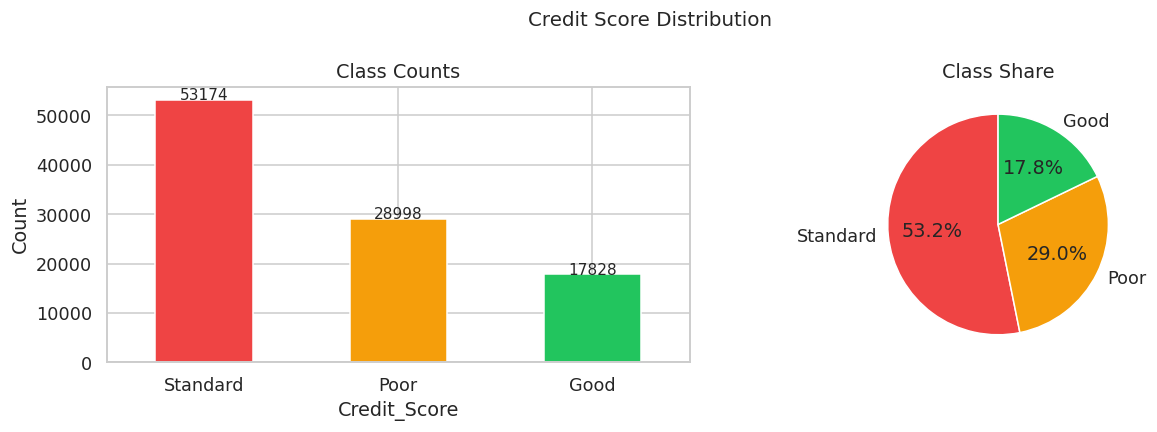

In [5]:
# 2.1 Target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
counts = df_raw["Credit_Score"].map(LABEL_MAP).value_counts()
counts.plot(kind="bar", ax=ax1, color=COLORS, edgecolor="white", rot=0)
ax1.set_title("Class Counts"); ax1.set_ylabel("Count")
for bar in ax1.patches:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             int(bar.get_height()), ha="center", fontsize=10)
ax2.pie(counts, labels=counts.index, autopct="%1.1f%%",
        colors=COLORS, startangle=90)
ax2.set_title("Class Share")
plt.suptitle("Credit Score Distribution", fontsize=13)
plt.tight_layout(); plt.show()


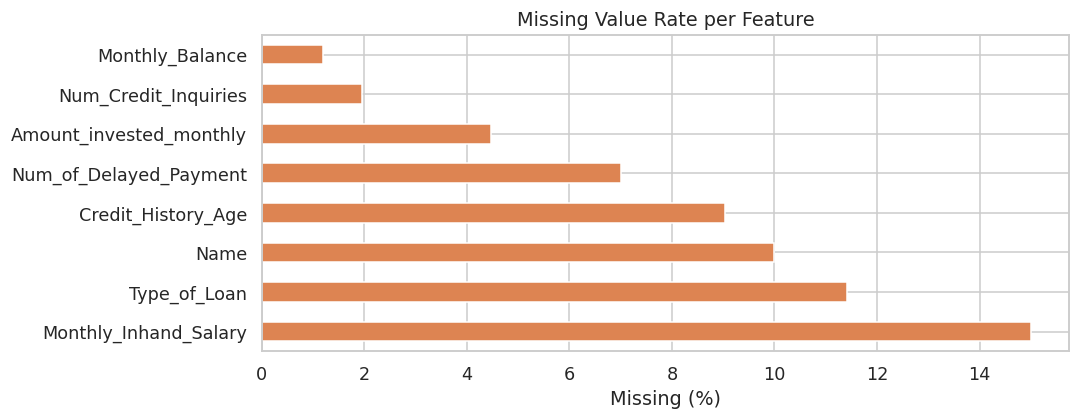

Monthly_Inhand_Salary      15.00
Type_of_Loan               11.41
Name                        9.98
Credit_History_Age          9.03
Num_of_Delayed_Payment      7.00
Amount_invested_monthly     4.48
Num_Credit_Inquiries        1.96
Monthly_Balance             1.20


In [6]:
# 2.2 Missing values
miss = (df_raw.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss>0]
plt.figure(figsize=(10,4))
miss.plot(kind="barh", color="#DD8452", edgecolor="white")
plt.xlabel("Missing (%)"); plt.title("Missing Value Rate per Feature")
plt.tight_layout(); plt.show()
print(miss.round(2).to_string())


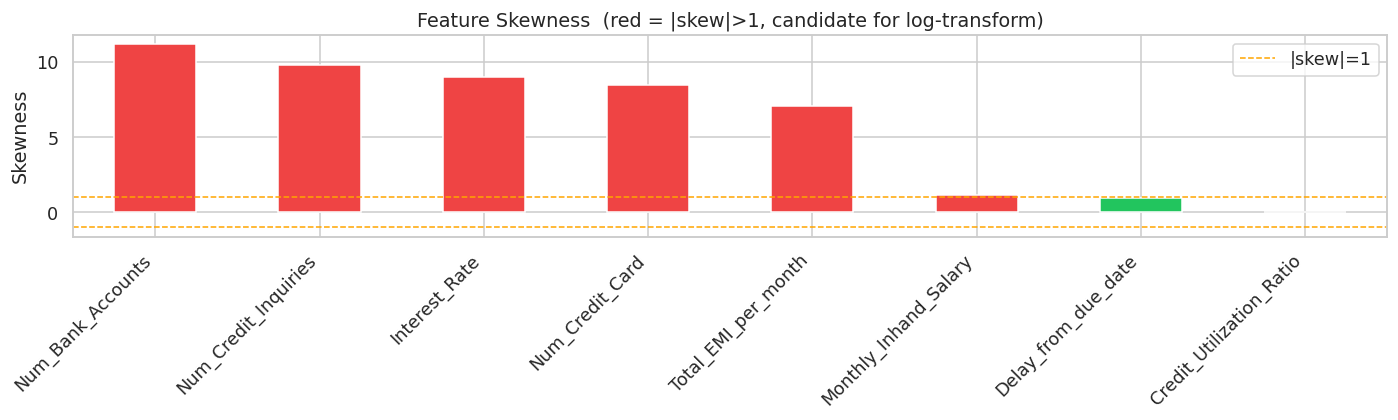

High-skew features (|skew|>1):
Num_Bank_Accounts        11.202
Num_Credit_Inquiries      9.786
Interest_Rate             9.006
Num_Credit_Card           8.458
Total_EMI_per_month       7.103
Monthly_Inhand_Salary     1.127


In [7]:
# 2.3 Skewness analysis
num_cols = df_raw.select_dtypes(include=np.number).columns.drop("Credit_Score")
skew_df  = df_raw[num_cols].skew().sort_values(ascending=False)
colors_skew = ["#ef4444" if abs(s)>1 else "#22c55e" for s in skew_df]
plt.figure(figsize=(13,4))
skew_df.plot(kind="bar", color=colors_skew)
plt.axhline(1,  color="orange", linestyle="--", linewidth=1, label="|skew|=1")
plt.axhline(-1, color="orange", linestyle="--", linewidth=1)
plt.title("Feature Skewness  (red = |skew|>1, candidate for log-transform)")
plt.ylabel("Skewness"); plt.xticks(rotation=45, ha="right")
plt.legend(); plt.tight_layout(); plt.show()
print("High-skew features (|skew|>1):")
print(skew_df[abs(skew_df)>1].round(3).to_string())


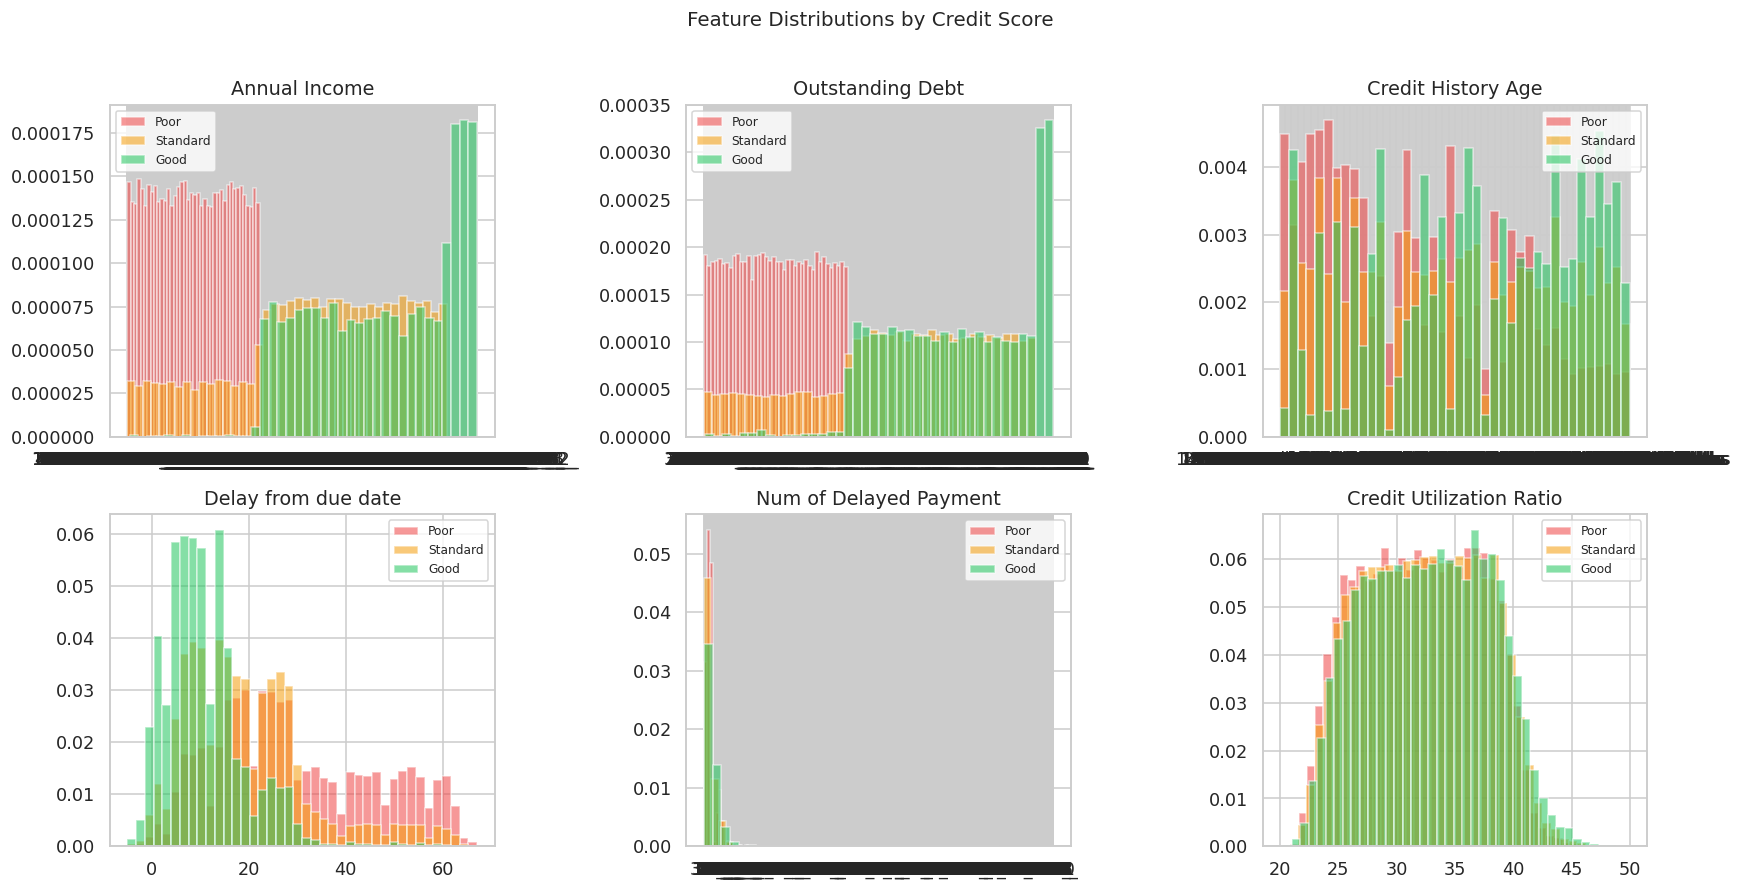

In [8]:
# 2.4 Feature distributions by credit score
NUM_FEATS = ["Annual_Income","Outstanding_Debt","Credit_History_Age",
             "Delay_from_due_date","Num_of_Delayed_Payment","Credit_Utilization_Ratio"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), NUM_FEATS):
    for i, (s, l) in enumerate(LABEL_MAP.items()):
        ax.hist(df_raw.loc[df_raw["Credit_Score"]==s, feat].dropna(),
                bins=40, alpha=0.55, label=l, color=COLORS[i], density=True)
    ax.set_title(feat.replace("_"," ")); ax.legend(fontsize=8)
plt.suptitle("Feature Distributions by Credit Score", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


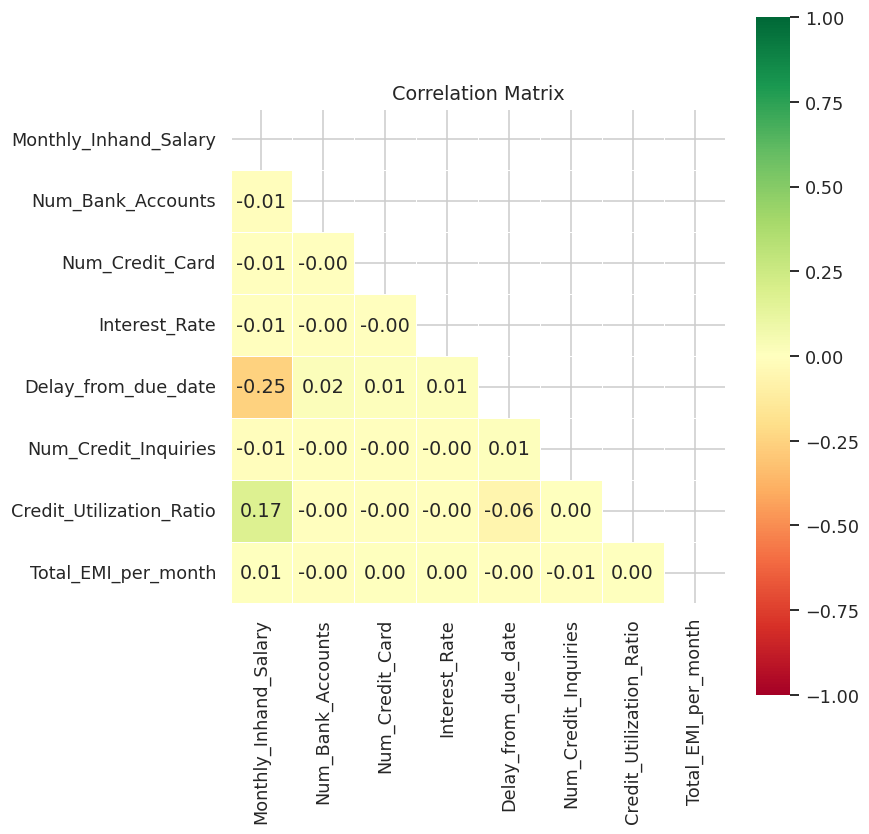

In [9]:
# 2.5 Correlation heatmap
corr = df_raw.select_dtypes(include=np.number).drop("Credit_Score",axis=1).corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)),
            annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()


## 3. Preprocessing
### 3.1 Linearisation (Log Transform)
Right-skewed features violate linear model assumptions. `log1p` maps them closer to normality.


df_lin created — shape: (100000, 28)


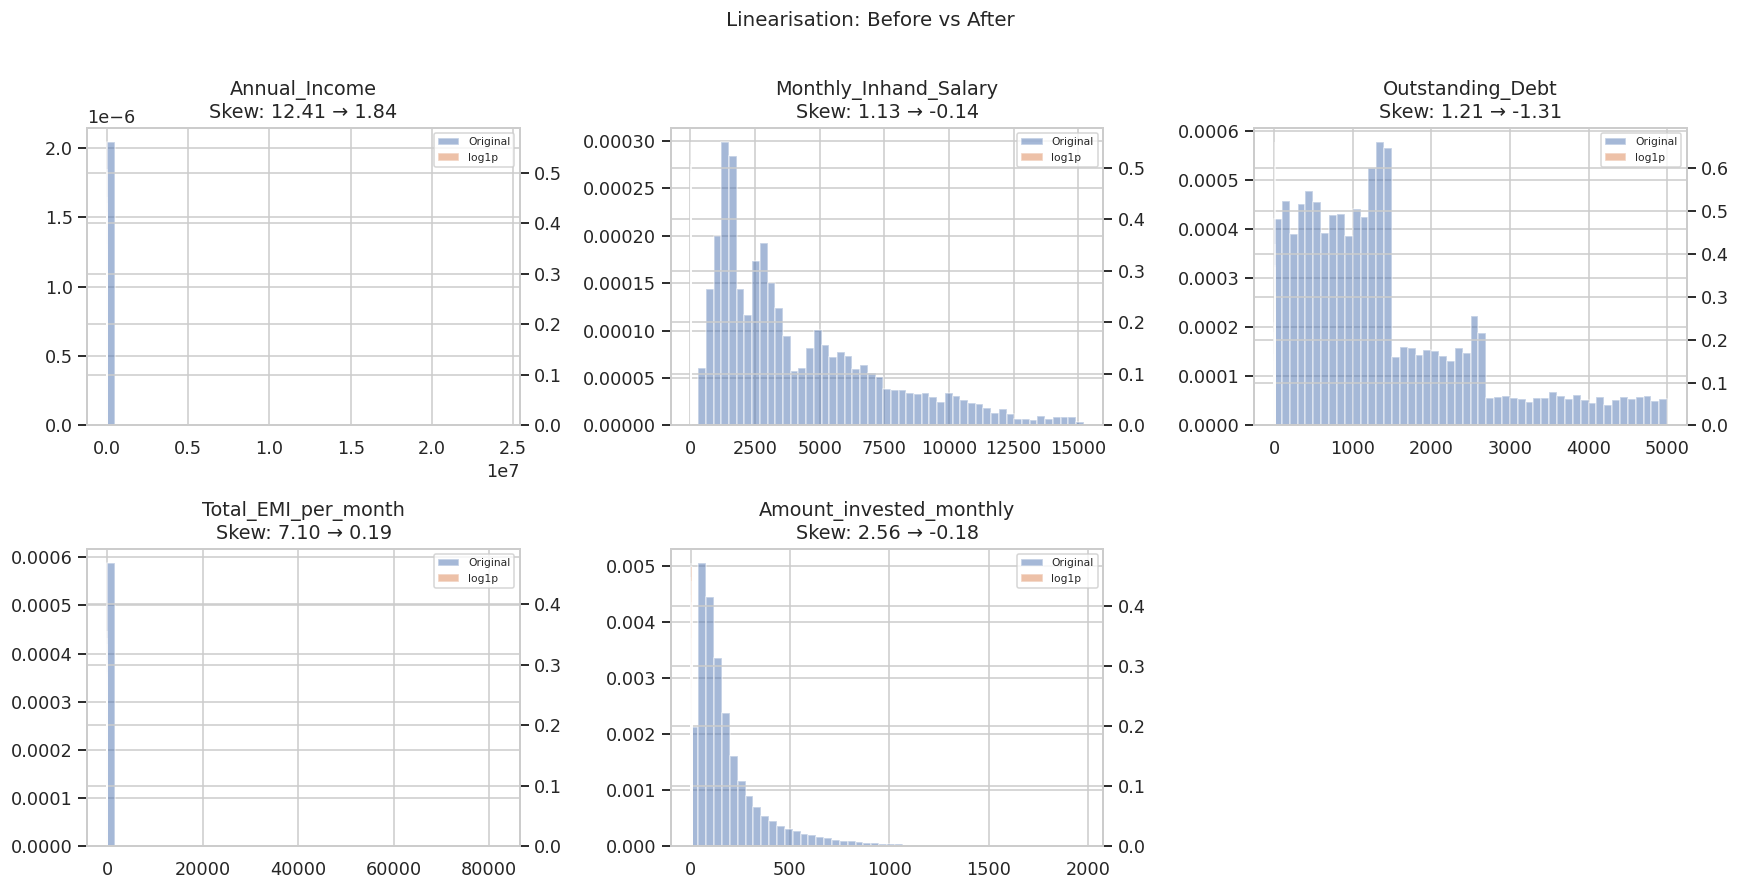

In [ ]:
# Define transform 
def apply_linearisation(df):
    df = df.copy()
    for col in LOG_FEATURES:
        if col in df.columns:
            # Convert messy strings to numbers on-the-fly, turning bad data to NaN
            numeric_col = pd.to_numeric(df[col], errors="coerce")
            df[col] = np.log1p(numeric_col.clip(lower=0))
    return df

# (assignment BEFORE visualisation) 
df_lin = apply_linearisation(df_raw)
print(f"df_lin created - shape: {df_lin.shape}")

# Visualise before vs after for the 5 log-transformed features 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, feat in enumerate(LOG_FEATURES):
    ax = axes[i//3][i%3]
    
    # Clean the plotting data to numeric and drop NaN values to prevent errors
    cleaned_feat = pd.to_numeric(df_raw[feat], errors="coerce").dropna()
    
    original    = cleaned_feat
    transformed = np.log1p(original.clip(lower=0))
    
    # 1. Plot original data on the primary X-axis
    ax.hist(original, bins=50, alpha=0.5, color="#4C72B0", label="Original", density=True)
    
    # FIX: 2. Create a secondary twin axis for the tiny log-transformed numbers
    ax2 = ax.twinx()
    ax2.hist(transformed, bins=50, alpha=0.5, color="#DD8452", label="log1p", density=True)
    
    ax.set_title(f"{feat}\nSkew: {original.skew():.2f} - {transformed.skew():.2f}")
    
    # FIX: 3. Combine legends from both axes so they display together cleanly
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")

axes[1][2].set_visible(False)      # 5 features, 6 axes - hide the last empty slot
plt.suptitle("Linearisation: Before vs After", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### 3.2 Re-binning (Ordinal Bucketing)

df_bin created — shape: (100000, 31)
New binned columns: ['Age_Group', 'Income_Bracket', 'Delay_Bucket']


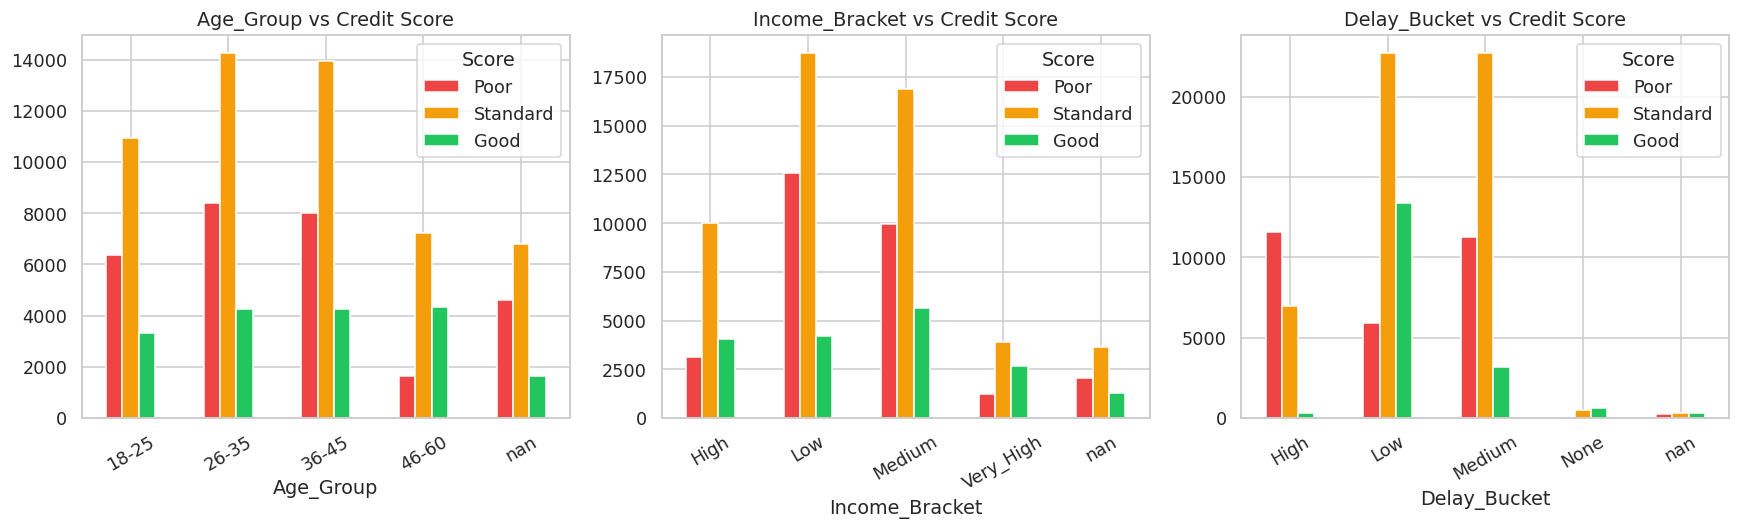

In [ ]:
# Define transform 
def apply_rebinning(df):
    df = df.copy()
    
    # FIX: Force Age to numeric to prevent string vs int comparison errors
    age_numeric = pd.to_numeric(df["Age"], errors="coerce")
    df["Age_Group"] = pd.cut(age_numeric,
        bins=[17,25,35,45,60,75],
        labels=["18-25","26-35","36-45","46-60","61-75"]).astype(str)
        
    # FIX: Force Annual_Income to numeric before performing the max comparison
    inc_numeric = pd.to_numeric(df["Annual_Income"], errors="coerce")
    inc_raw = np.expm1(inc_numeric) if inc_numeric.max() < 30 else inc_numeric
    df["Income_Bracket"] = pd.cut(inc_raw.fillna(0), # fillna handles coerced NaN values
        bins=[0,30000,70000,120000,1e9],
        labels=["Low","Medium","High","Very_High"]).astype(str)
        
    # FIX: Force Delay_from_due_date to numeric before filling missing values and binning
    delay_numeric = pd.to_numeric(df["Delay_from_due_date"], errors="coerce")
    df["Delay_Bucket"] = pd.cut(delay_numeric.fillna(0),
        bins=[-1,0,15,30,62],
        labels=["None","Low","Medium","High"]).astype(str)
    return df

# (assignment BEFORE visualisation)
df_bin = apply_rebinning(df_lin)
print(f"df_bin created - shape: {df_bin.shape}")
print("New binned columns:", ["Age_Group","Income_Bracket","Delay_Bucket"])

# Visualise bins vs credit score 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ["Age_Group","Income_Bracket","Delay_Bucket"]):
    ct = pd.crosstab(df_bin[feat], df_bin["Credit_Score"].map(LABEL_MAP))
    for c in CLASS_NAMES:
        if c not in ct.columns: ct[c] = 0
    ct[CLASS_NAMES].plot(kind="bar", ax=ax, color=COLORS, edgecolor="white", rot=30)
    ax.set_title(f"{feat} vs Credit Score"); ax.legend(title="Score")
plt.tight_layout(); plt.show()


### 3.3 Encoding & Imputation

In [ ]:
# Guard: re-run upstream steps if this cell is run out of order 
if "df_raw" not in dir():
    df_raw = generate_dataset(n=10_000, seed=SEED)
if "df_lin" not in dir():
    df_lin = apply_linearisation(df_raw)
if "df_bin" not in dir():
    df_bin = apply_rebinning(df_lin)

# Encode 
le_dict = {}

def encode_df(df):
    df = df.copy()
    for col in CAT_COLS:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            le_dict[col] = le
    return df

df_enc = encode_df(df_bin)

# Impute 
feature_cols = [c for c in df_enc.columns if c != "Credit_Score"]
imputer      = SimpleImputer(strategy="most_frequent")
df_enc[feature_cols] = imputer.fit_transform(df_enc[feature_cols])

print(f"Missing values remaining : {df_enc.isnull().sum().sum()}")
print(f"Shape after encoding+imputation : {df_enc.shape}")
df_enc.head()


Missing values remaining : 0
Shape after encoding+imputation : (100000, 31)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Age_Group,Income_Bracket,Delay_Bucket
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,12,9.858235,7.509797,3,...,22 Years and 1 Months,1,3.923456,4.399563,High_spent_Small_value_payments,312.49408867943663,2,0,1,1
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,12,9.858235,7.738949,3,...,15 Years and 11 Months,1,3.923456,4.781476,Low_spent_Large_value_payments,284.62916249607184,2,0,1,4
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,12,9.858235,7.738949,3,...,22 Years and 3 Months,1,3.923456,4.415214,Low_spent_Medium_value_payments,331.2098628537912,2,4,1,1
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,12,9.858235,7.738949,3,...,22 Years and 4 Months,1,3.923456,5.300605,Low_spent_Small_value_payments,223.45130972736786,2,0,1,1
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,12,9.858235,7.509797,3,...,22 Years and 5 Months,1,3.923456,3.747624,High_spent_Medium_value_payments,341.48923103222177,2,0,1,1


### 3.4 Normalisation Comparison

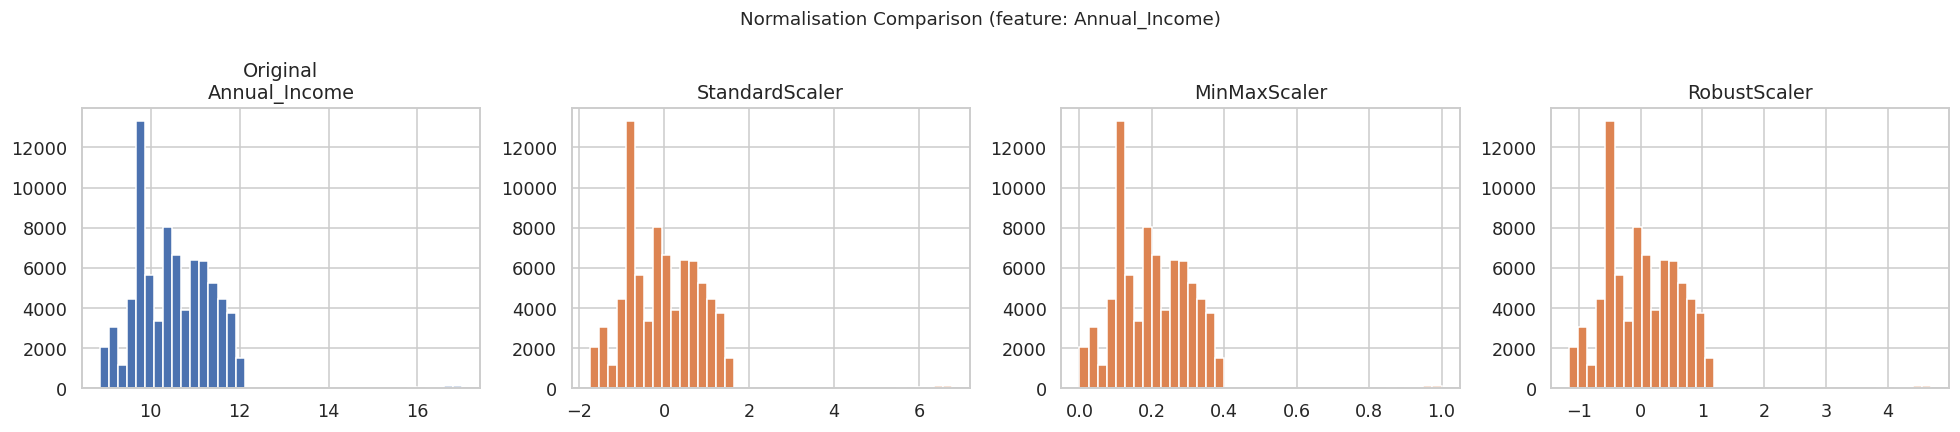

Using StandardScaler for the pipeline.
X_tr_s shape: (80000, 30)  |  X_te_s shape: (20000, 30)


In [ ]:
# Guard 
if "df_enc" not in dir():
    df_raw = generate_dataset(n=10_000, seed=SEED)
    df_enc = encode_df(apply_rebinning(apply_linearisation(df_raw)))
    fcols  = [c for c in df_enc.columns if c != "Credit_Score"]
    
    for col in fcols:
        df_enc[col] = pd.to_numeric(df_enc[col], errors="coerce")
        
    df_enc[fcols] = SimpleImputer(strategy="median").fit_transform(df_enc[fcols])

# Force columns to numeric and fill any lingering NaNs with 0 to prevent plotting crashes
all_features = [c for c in df_enc.columns if c != "Credit_Score"]
for col in all_features:
    df_enc[col] = pd.to_numeric(df_enc[col], errors="coerce").fillna(0)

# Safely extract numerical data matrices
X_raw = df_enc.drop("Credit_Score", axis=1).select_dtypes(include=[np.number])
y     = df_enc["Credit_Score"]

X_tr, X_te, y_tr, y_te = train_test_split(X_raw, y, test_size=0.2,stratify=y, random_state=SEED)

# FIX: Dynamically find where "Annual_Income" is, or fallback to index 2 if missing
if "Annual_Income" in X_tr.columns:
    feat_idx = X_tr.columns.get_loc("Annual_Income")
    feat_name = "Annual_Income"
else:
    feat_idx = 2
    feat_name = X_raw.columns[feat_idx]

# Compare three scalers on distribution of the feature
scalers = {"StandardScaler": StandardScaler(),
           "MinMaxScaler":   MinMaxScaler(),
           "RobustScaler":   RobustScaler()}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# FIX: Plot using the verified column index location
axes[0].hist(X_tr.iloc[:, feat_idx], bins=40, color="#4C72B0")
axes[0].set_title(f"Original\n{feat_name}")

for ax, (name, sc) in zip(axes[1:], scalers.items()):
    X_sc = sc.fit_transform(X_tr)
    ax.hist(X_sc[:, feat_idx], bins=40, color="#DD8452")
    ax.set_title(name)

plt.suptitle(f"Normalisation Comparison (feature: {feat_name})", fontsize=12)
plt.tight_layout(); plt.show()

# Use StandardScaler going forward
scaler   = StandardScaler()
X_tr_s   = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns)
X_te_s   = pd.DataFrame(scaler.transform(X_te),     columns=X_te.columns)
print("Using StandardScaler for the pipeline.")
print(f"X_tr_s shape: {X_tr_s.shape}  |  X_te_s shape: {X_te_s.shape}")


## 4. Feature Engineering

In [ ]:
# Guard 
if "X_tr_s" not in dir():
    raise RuntimeError("Run Section 3 cells first, then re-run this cell.")

def add_features(df):
    df = df.copy()
    df["Debt_to_Income"]       = df["Outstanding_Debt"]        / (df["Annual_Income"]         + 1e-3)
    df["EMI_to_Income"]        = df["Total_EMI_per_month"]      / (df["Monthly_Inhand_Salary"] + 1e-3)
    df["Delayed_per_Loan"]     = df["Num_of_Delayed_Payment"]   / (df["Num_of_Loan"]           + 1)
    df["Investment_to_Income"] = df["Amount_invested_monthly"]  / (df["Monthly_Inhand_Salary"] + 1e-3)
    df["Cards_per_Account"]    = df["Num_Credit_Card"]          / (df["Num_Bank_Accounts"]     + 1)
    df["Util_x_Delay"]         = df["Credit_Utilization_Ratio"] * df["Delay_from_due_date"].fillna(0)
    df["Debt_x_Inquiries"]     = df["Outstanding_Debt"]         * df["Num_Credit_Inquiries"].fillna(0)
    return df

X_tr_fe = add_features(X_tr_s)
X_te_fe = add_features(X_te_s)

NEW_FEATS = ["Debt_to_Income","EMI_to_Income","Delayed_per_Loan",
             "Investment_to_Income","Cards_per_Account","Util_x_Delay","Debt_x_Inquiries"]
print(f"Engineered {len(NEW_FEATS)} new features - total now: {X_tr_fe.shape[1]}")
X_tr_fe[NEW_FEATS].describe().round(3)


Engineered 7 new features — total now: 37


,Debt_to_Income,EMI_to_Income,Delayed_per_Loan,Investment_to_Income,Cards_per_Account,Util_x_Delay,Debt_x_Inquiries
count,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000,80000.000
mean,-19.388,-2.222,0.002,1.405,0.000,-0.064,0.005
std,2460.384,249.602,1.006,1318.391,1.107,0.989,1.066
min,-311187.605,-27903.650,-29.456,-83174.647,-0.202,-6.016,-77.635
25%,-0.979,-0.223,-0.094,-0.376,-0.160,-0.473,-0.061
50%,-0.185,0.277,-0.066,0.242,-0.146,-0.007,-0.023
75%,0.831,0.782,-0.046,0.823,-0.132,0.386,0.059
max,1380.179,2160.321,20.903,294013.893,13.219,5.367,18.636


## 5. Feature Selection
Three complementary methods - Mutual Information, RF Importance, and RFECV.


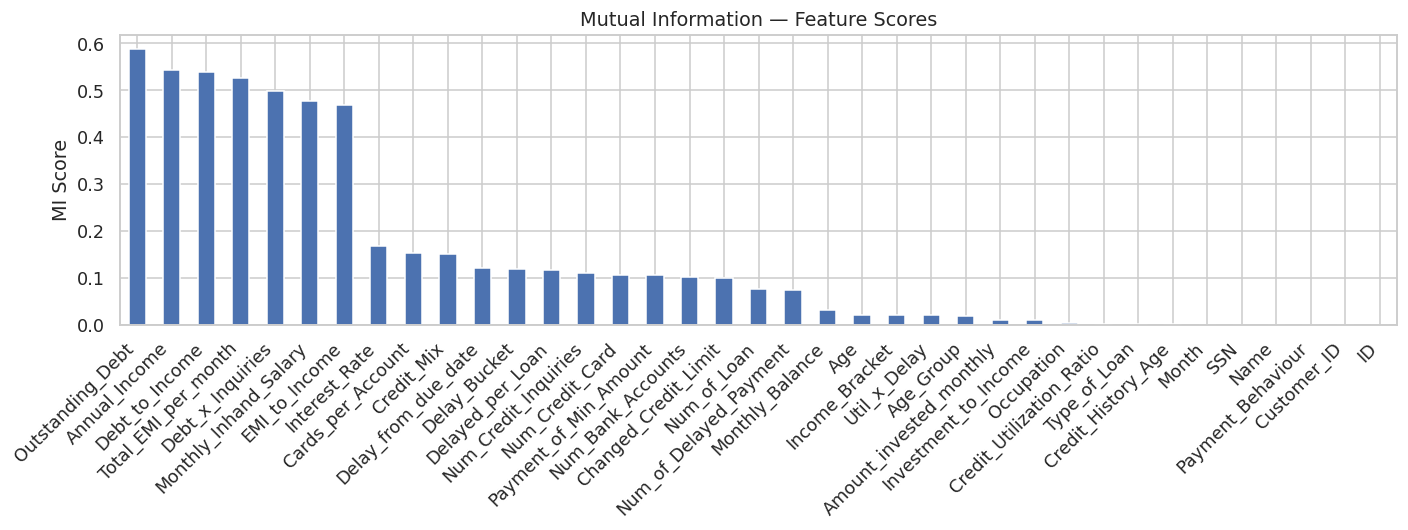

Mutual Info selected 24 features


In [ ]:
# Guard 
if "X_tr_fe" not in dir():
    raise RuntimeError("Run Sections 3 and 4 first.")

# 5.1 Mutual Information
mi_scores = mutual_info_classif(X_tr_fe, y_tr, random_state=SEED)
mi_df     = pd.Series(mi_scores, index=X_tr_fe.columns).sort_values(ascending=False)
plt.figure(figsize=(13,5))
mi_df.plot(kind="bar", color="#4C72B0", edgecolor="white")
plt.title("Mutual Information - Feature Scores")
plt.ylabel("MI Score"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()
mi_selected = mi_df[mi_df > mi_df.quantile(0.35)].index.tolist()
print(f"Mutual Info selected {len(mi_selected)} features")


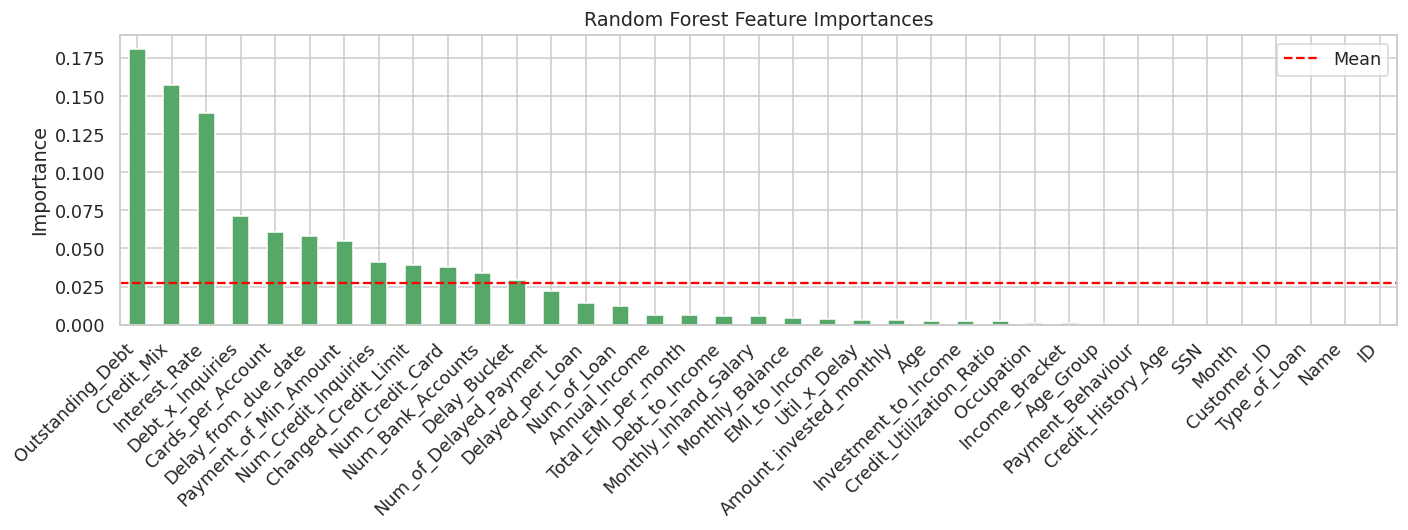

RF importance selected 12 features


In [16]:
# 5.2 Random Forest Feature Importance
rf_fi = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1)
rf_fi.fit(X_tr_fe, y_tr)
fi_df = pd.Series(rf_fi.feature_importances_, index=X_tr_fe.columns).sort_values(ascending=False)
plt.figure(figsize=(13,5))
fi_df.plot(kind="bar", color="#55A868", edgecolor="white")
plt.title("Random Forest Feature Importances"); plt.ylabel("Importance")
plt.axhline(fi_df.mean(), color="red", linestyle="--", label="Mean")
plt.xticks(rotation=45, ha="right"); plt.legend(); plt.tight_layout(); plt.show()
fi_selected = fi_df[fi_df > fi_df.mean()].index.tolist()
print(f"RF importance selected {len(fi_selected)} features")


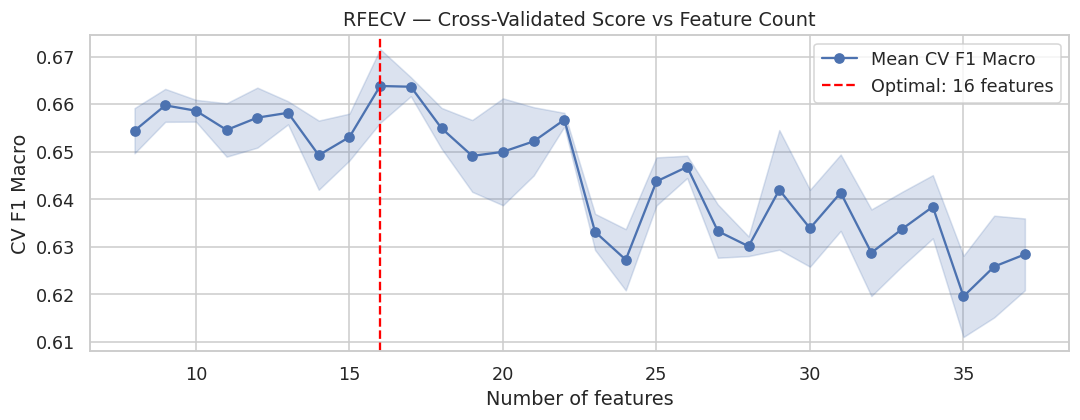

RFECV optimal feature count: 16
Selected: ['Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Payment_of_Min_Amount', 'Delay_Bucket', 'Delayed_per_Loan', 'Cards_per_Account', 'Debt_x_Inquiries']


In [ ]:
# 5.3 RFECV (Recursive Feature Elimination with Cross-Validation)
rf_rfe = RandomForestClassifier(n_estimators=60, max_depth=6, random_state=SEED, n_jobs=-1)
rfecv  = RFECV(estimator=rf_rfe,
               cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
               scoring="f1_macro", n_jobs=-1, min_features_to_select=8)
rfecv.fit(X_tr_fe, y_tr)
rfe_selected = X_tr_fe.columns[rfecv.support_].tolist()

# CV score vs number of features
n_start = rfecv.min_features_to_select
cv_scores = rfecv.cv_results_["mean_test_score"]
cv_std    = rfecv.cv_results_["std_test_score"]
x_range   = range(n_start, n_start + len(cv_scores))

plt.figure(figsize=(10,4))
plt.plot(x_range, cv_scores, "o-", color="#4C72B0", label="Mean CV F1 Macro")
plt.fill_between(x_range, cv_scores-cv_std, cv_scores+cv_std, alpha=0.2, color="#4C72B0")
plt.axvline(len(rfe_selected), color="red", linestyle="--",
            label=f"Optimal: {len(rfe_selected)} features")
plt.xlabel("Number of features"); plt.ylabel("CV F1 Macro")
plt.title("RFECV - Cross-Validated Score vs Feature Count")
plt.legend(); plt.tight_layout(); plt.show()
print(f"RFECV optimal feature count: {len(rfe_selected)}")
print("Selected:", rfe_selected)


In [ ]:
# Final selection - use RFECV result (most principled)
SELECTED = rfe_selected
X_tr_sel = X_tr_fe[SELECTED].copy()
X_te_sel = X_te_fe[SELECTED].copy()
print(f"Final dataset: {X_tr_sel.shape[1]} features  |  "
      f"{X_tr_sel.shape[0]} train rows  |  {X_te_sel.shape[0]} test rows")


Final dataset: 16 features  |  80000 train rows  |  20000 test rows


## 6. Class Imbalance - SMOTE

Before SMOTE:
Credit_Score
Standard    42539
Poor        23199
Good        14262

After SMOTE:
Credit_Score
Standard    42539
Poor        42539
Good        42539


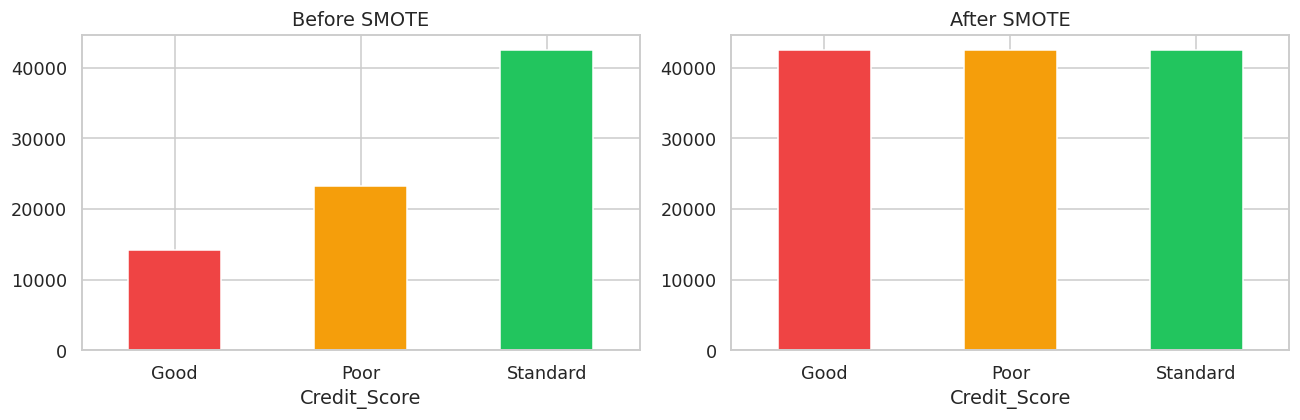

In [ ]:
if "X_tr_sel" not in dir():
    raise RuntimeError("Run Sections 3–5 first.")

print("Before SMOTE:"); print(y_tr.value_counts().rename(LABEL_MAP).to_string())

smote         = SMOTE(random_state=SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_tr_sel, y_tr)

print("\nAfter SMOTE:"); print(pd.Series(y_tr_sm).value_counts().rename(LABEL_MAP).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr.value_counts().rename(LABEL_MAP).sort_index().plot(
    kind="bar", ax=axes[0], color=COLORS, edgecolor="white", rot=0, title="Before SMOTE")
pd.Series(y_tr_sm).value_counts().rename(LABEL_MAP).sort_index().plot(
    kind="bar", ax=axes[1], color=COLORS, edgecolor="white", rot=0, title="After SMOTE")
plt.tight_layout(); plt.show()


## 7. Model Training - All Classifiers + Optuna Tuning

In [ ]:
if "X_tr_sm" not in dir():
    raise RuntimeError("Run Sections 3–6 first.")

# Optuna: tune XGBoost (30 trials)
def xgb_objective(trial):
    p = dict(
        n_estimators     = trial.suggest_int("n_estimators", 100, 400),
        max_depth        = trial.suggest_int("max_depth", 3, 9),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        reg_alpha        = trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        eval_metric="mlogloss", random_state=SEED, n_jobs=-1,
    )
    return cross_val_score(
        xgb.XGBClassifier(**p), X_tr_sm, y_tr_sm,
        cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
        scoring="roc_auc_ovr", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

best_xgb_params = {**study.best_params,
                   "eval_metric": "mlogloss", "random_state": SEED, "n_jobs": -1}
print(f"\nBest XGBoost CV AUC : {study.best_value:.4f}")
print("Best params:", best_xgb_params)


  0%|          | 0/30 [00:00<?, ?it/s]


Best XGBoost CV AUC : 0.9542
Best params: {'n_estimators': 378, 'max_depth': 9, 'learning_rate': 0.19107001734152512, 'subsample': 0.6320408163578337, 'colsample_bytree': 0.7749144139499511, 'min_child_weight': 4, 'reg_alpha': 2.97010536047504, 'reg_lambda': 0.015352917491391373, 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1}


In [21]:
# Train all 9 base models + evaluate
CV5 = StratifiedKFold(5, shuffle=True, random_state=SEED)

base_models = {
    "Logistic Regression" : LogisticRegression(max_iter=2000, C=1.0, random_state=SEED),
    "Random Forest"        : RandomForestClassifier(n_estimators=200, max_depth=10,
                                 min_samples_leaf=4, random_state=SEED, n_jobs=-1),
    "Extra Trees"          : ExtraTreesClassifier(n_estimators=200, max_depth=10,
                                 random_state=SEED, n_jobs=-1),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                 learning_rate=0.08, random_state=SEED),
    "XGBoost (tuned)"      : xgb.XGBClassifier(**best_xgb_params),
    "LightGBM"             : lgb.LGBMClassifier(n_estimators=200, max_depth=6,
                                 learning_rate=0.05, random_state=SEED,
                                 n_jobs=-1, verbose=-1),
    "Naive Bayes"          : GaussianNB(),
    "KNN"                  : KNeighborsClassifier(n_neighbors=9, n_jobs=-1)
}

results = {}
X_tr_np = X_tr_sm if isinstance(X_tr_sm, np.ndarray) else np.array(X_tr_sm)
X_te_np = X_te_sel.values

for name, mdl in base_models.items():
    mdl.fit(X_tr_np, y_tr_sm)
    preds = mdl.predict(X_te_np)
    proba = mdl.predict_proba(X_te_np)
    cv_s  = cross_val_score(mdl, X_tr_np, y_tr_sm,
                            cv=CV5, scoring="roc_auc_ovr", n_jobs=-1)
    results[name] = dict(
        model=mdl, preds=preds, proba=proba,
        accuracy  = accuracy_score(y_te, preds),
        f1_macro  = f1_score(y_te, preds, average="macro"),
        precision = precision_score(y_te, preds, average="macro"),
        recall    = recall_score(y_te, preds, average="macro"),
        roc_auc   = roc_auc_score(y_te, proba, multi_class="ovr", average="macro"),
        cv_mean   = cv_s.mean(), cv_std=cv_s.std(),
    )
    print(f"{name:25s}  acc={results[name]['accuracy']:.4f}  "
          f"f1={results[name]['f1_macro']:.4f}  "
          f"auc={results[name]['roc_auc']:.4f}  "
          f"cv={results[name]['cv_mean']:.4f}±{results[name]['cv_std']:.3f}")


Logistic Regression        acc=0.5706  f1=0.5707  auc=0.7610  cv=0.7791±0.001
Random Forest              acc=0.7018  f1=0.6936  auc=0.8583  cv=0.8941±0.001
Extra Trees                acc=0.6376  f1=0.6324  auc=0.8054  cv=0.8259±0.002
Gradient Boosting          acc=0.7218  f1=0.7064  auc=0.8588  cv=0.9173±0.000
XGBoost (tuned)            acc=0.7825  f1=0.7699  auc=0.9104  cv=0.9570±0.000


/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have va

LightGBM                   acc=0.7180  f1=0.7020  auc=0.8607  cv=0.9196±0.001
Naive Bayes                acc=0.5456  f1=0.5471  auc=0.7388  cv=0.7590±0.001
KNN                        acc=0.6329  f1=0.6269  auc=0.8113  cv=0.8810±0.002


## 8. Ensemble Methods

### 8.1 Soft Voting Ensemble

In [ ]:
if "results" not in dir():
    raise RuntimeError("Run Section 7 first.")

top4_names = sorted(results, key=lambda n: results[n]["roc_auc"], reverse=True)[:4]
print("Top-4 models for ensemble:", top4_names)

voting = VotingClassifier(
    estimators=[(n, base_models[n]) for n in top4_names],
    voting="soft", n_jobs=-1)
voting.fit(X_tr_np, y_tr_sm)
vp = voting.predict(X_te_np); vr = voting.predict_proba(X_te_np)
cv_v = cross_val_score(voting, X_tr_np, y_tr_sm, cv=CV5,
                       scoring="roc_auc_ovr", n_jobs=-1)
results["Voting Ensemble"] = dict(
    model=voting, preds=vp, proba=vr,
    accuracy=accuracy_score(y_te,vp),   f1_macro=f1_score(y_te,vp,average="macro"),
    precision=precision_score(y_te,vp,average="macro"),
    recall=recall_score(y_te,vp,average="macro"),
    roc_auc=roc_auc_score(y_te,vr,multi_class="ovr",average="macro"),
    cv_mean=cv_v.mean(), cv_std=cv_v.std())
print(f"Voting Ensemble  -  acc={results['Voting Ensemble']['accuracy']:.4f}  "
      f"auc={results['Voting Ensemble']['roc_auc']:.4f}")


Top-4 models for ensemble: ['XGBoost (tuned)', 'LightGBM', 'Gradient Boosting', 'Random Forest']


/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have va

Voting Ensemble  →  acc=0.7558  auc=0.8895


### 8.2 Model Stacking (Meta-Learner = Logistic Regression)

In [ ]:
stacking = StackingClassifier(
    estimators     = [(n, base_models[n]) for n in top4_names],
    final_estimator = LogisticRegression(max_iter=2000, C=0.5, random_state=SEED),
    cv=5, passthrough=False, n_jobs=-1)
stacking.fit(X_tr_np, y_tr_sm)
sp = stacking.predict(X_te_np); sr = stacking.predict_proba(X_te_np)
cv_st = cross_val_score(stacking, X_tr_np, y_tr_sm, cv=CV5,
                        scoring="roc_auc_ovr", n_jobs=-1)
results["Stacking"] = dict(
    model=stacking, preds=sp, proba=sr,
    accuracy=accuracy_score(y_te,sp),   f1_macro=f1_score(y_te,sp,average="macro"),
    precision=precision_score(y_te,sp,average="macro"),
    recall=recall_score(y_te,sp,average="macro"),
    roc_auc=roc_auc_score(y_te,sr,multi_class="ovr",average="macro"),
    cv_mean=cv_st.mean(), cv_std=cv_st.std())
print(f"Stacking  -  acc={results['Stacking']['accuracy']:.4f}  "
      f"auc={results['Stacking']['roc_auc']:.4f}")


/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/r0s1ta/anaconda3/envs/learn-env/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have va

Stacking  →  acc=0.7858  auc=0.9068


## 9. Comprehensive Model Evaluation

In [ ]:
if "Stacking" not in results:
    raise RuntimeError("Run Sections 7 and 8 first.")

# 9.1 Full metrics table
metrics_df = pd.DataFrame({
    n: {"Accuracy": round(v["accuracy"],4), "F1 Macro":  round(v["f1_macro"],4),
        "Precision":round(v["precision"],4), "Recall":    round(v["recall"],4),
        "ROC-AUC":  round(v["roc_auc"],4),
        "CV AUC":   f'{v["cv_mean"]:.4f}±{v["cv_std"]:.3f}'}
    for n, v in results.items()
}).T.sort_values("ROC-AUC", ascending=False)

display(metrics_df)
best_name = metrics_df.index[0]
print(f"\n Best model: {best_name}")


,Accuracy,F1 Macro,Precision,Recall,ROC-AUC,CV AUC
XGBoost (tuned),0.7825,0.7699,0.7711,0.7689,0.9104,0.9570±0.000
Stacking,0.7858,0.7761,0.7714,0.7813,0.9068,0.9533±0.000
Voting Ensemble,0.7558,0.7423,0.7304,0.7616,0.8895,0.9391±0.000
LightGBM,0.718,0.702,0.6935,0.7166,0.8607,0.9196±0.001
Gradient Boosting,0.7218,0.7064,0.6978,0.7206,0.8588,0.9173±0.000
Random Forest,0.7018,0.6936,0.6829,0.7373,0.8583,0.8941±0.001
KNN,0.6329,0.6269,0.6204,0.6735,0.8113,0.8810±0.002
Extra Trees,0.6376,0.6324,0.6271,0.6838,0.8054,0.8259±0.002
Logistic Regression,0.5706,0.5707,0.5733,0.6326,0.761,0.7791±0.001
Naive Bayes,0.5456,0.5471,0.5597,0.6157,0.7388,0.7590±0.001



🏆  Best model: XGBoost (tuned)


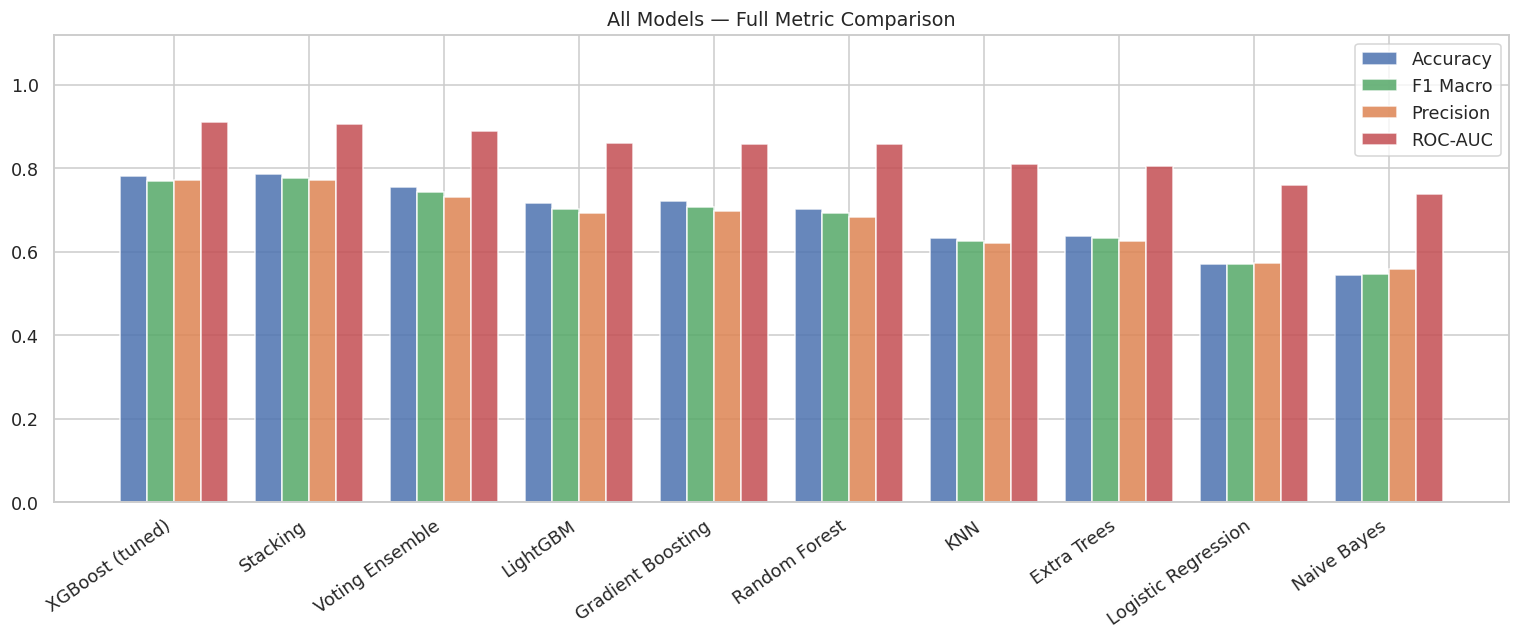

In [ ]:
# 9.2 All-model comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))
names = list(metrics_df.index)
x = np.arange(len(names)); w = 0.2
for i, (metric, col) in enumerate([("Accuracy","#4C72B0"),("F1 Macro","#55A868"),
                                     ("Precision","#DD8452"),("ROC-AUC","#C44E52")]):
    ax.bar(x+i*w, metrics_df[metric].astype(float), w, label=metric, color=col, alpha=0.85)
ax.set_xticks(x+1.5*w); ax.set_xticklabels(names, rotation=35, ha="right")
ax.set_ylim(0, 1.12); ax.set_title("All Models - Full Metric Comparison")
ax.legend(); plt.tight_layout(); plt.show()


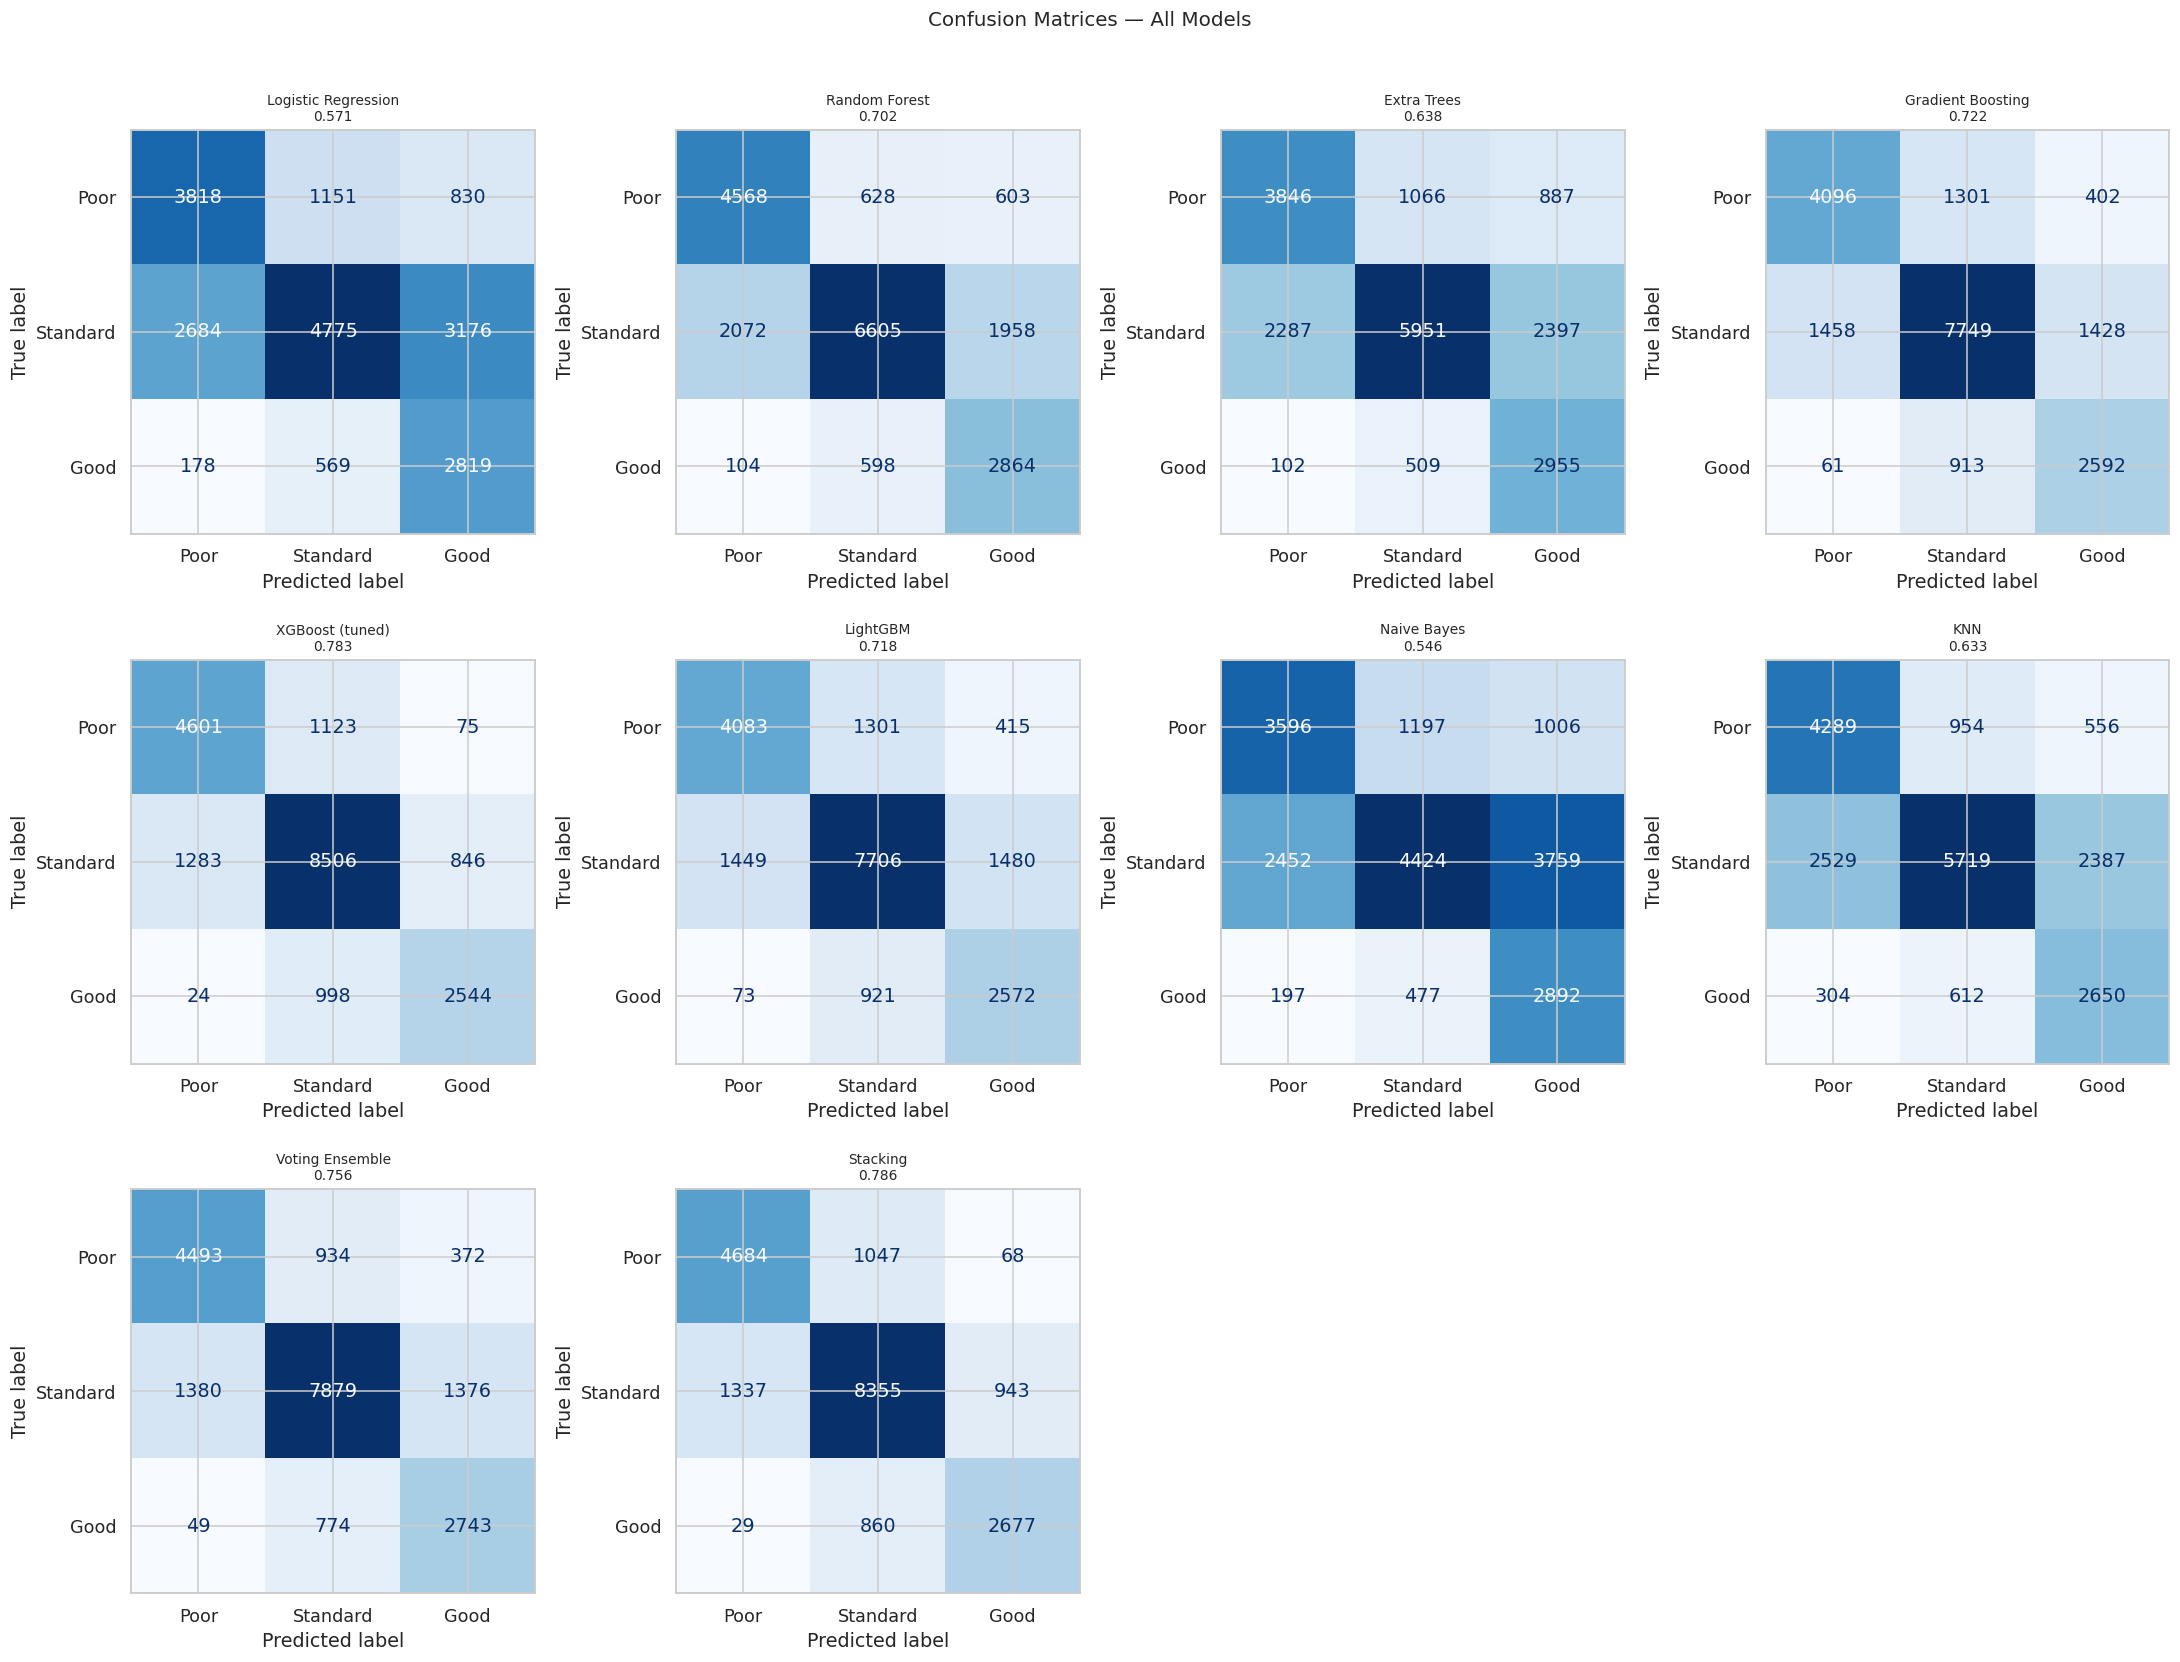

In [ ]:
# 9.3 Confusion matrices - all models
nc = 4; nr = math.ceil(len(results)/nc)
fig, axes = plt.subplots(nr, nc, figsize=(20, 5*nr))
for ax, (name, res) in zip(axes.ravel(), results.items()):
    cm = confusion_matrix(y_te, res["preds"])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\n{res['accuracy']:.3f}", fontsize=9)
for ax in axes.ravel()[len(results):]: ax.set_visible(False)
plt.suptitle("Confusion Matrices - All Models", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


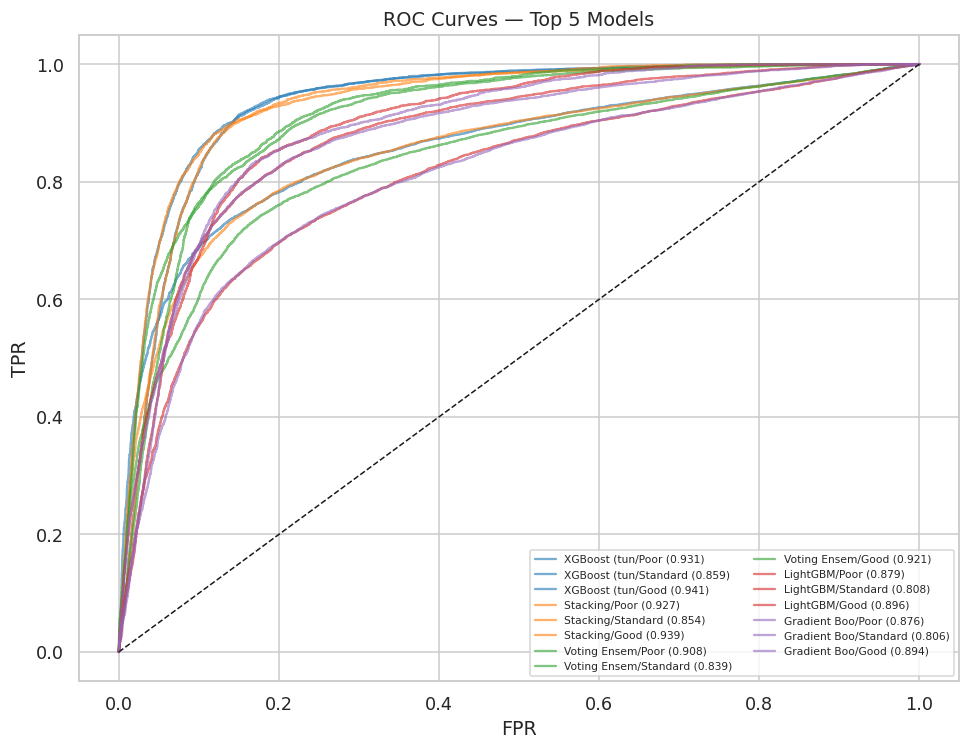

In [ ]:
# 9.4 ROC curves - top 5 models
top5   = list(metrics_df.head(5).index)
y_bin  = label_binarize(y_te, classes=[0,1,2])
cmap   = plt.cm.tab10
fig, ax = plt.subplots(figsize=(9,7))
for i, nm in enumerate(top5):
    for ci, cn in enumerate(CLASS_NAMES):
        fpr,tpr,_ = roc_curve(y_bin[:,ci], results[nm]["proba"][:,ci])
        auc_i = roc_auc_score(y_bin[:,ci], results[nm]["proba"][:,ci])
        ax.plot(fpr, tpr, color=cmap(i), alpha=0.6, lw=1.5,
                label=f"{nm[:12]}/{cn} ({auc_i:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set(xlabel="FPR",ylabel="TPR",title="ROC Curves - Top 5 Models")
ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()


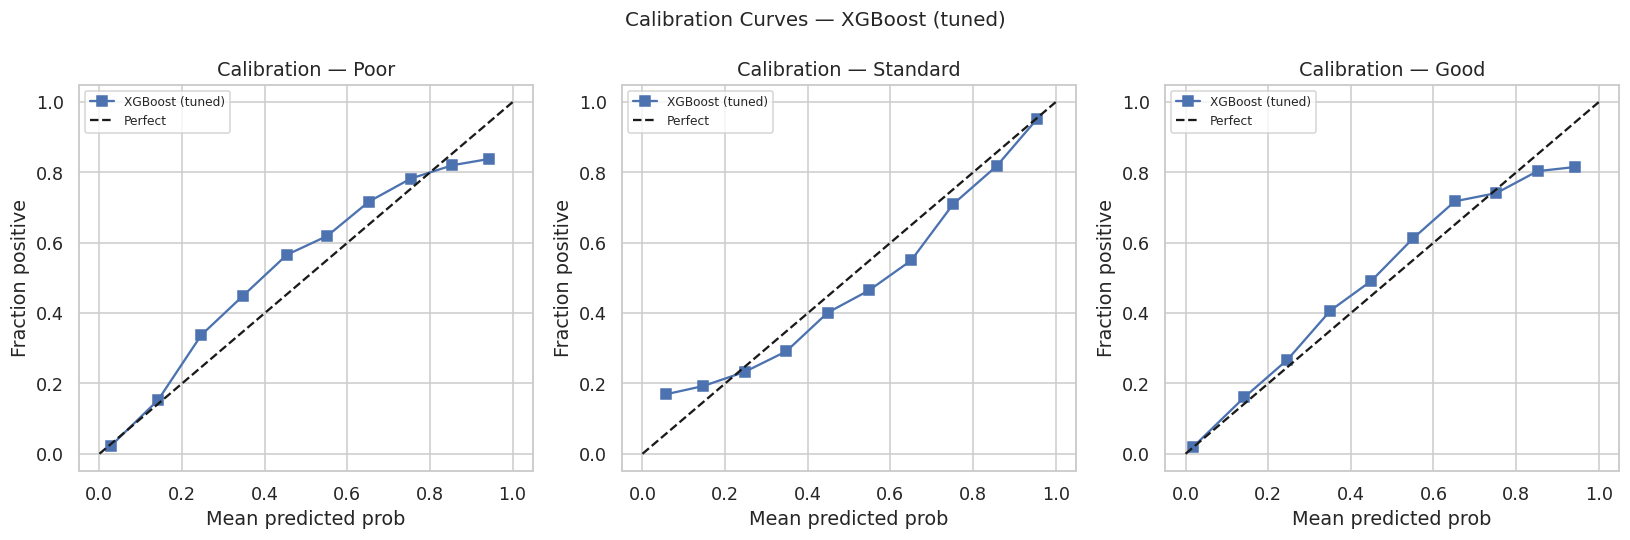

In [ ]:
# 9.5 Calibration curves - best model
best_res = results[best_name]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    frac_pos, mean_pred = calibration_curve(y_bin[:,i],
                                             best_res["proba"][:,i], n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", color="#4C72B0", label=best_name[:15])
    ax.plot([0,1],[0,1],"k--",label="Perfect")
    ax.set(title=f"Calibration - {cls}",
           xlabel="Mean predicted prob", ylabel="Fraction positive")
    ax.legend(fontsize=8)
plt.suptitle(f"Calibration Curves - {best_name}",fontsize=13)
plt.tight_layout(); plt.show()


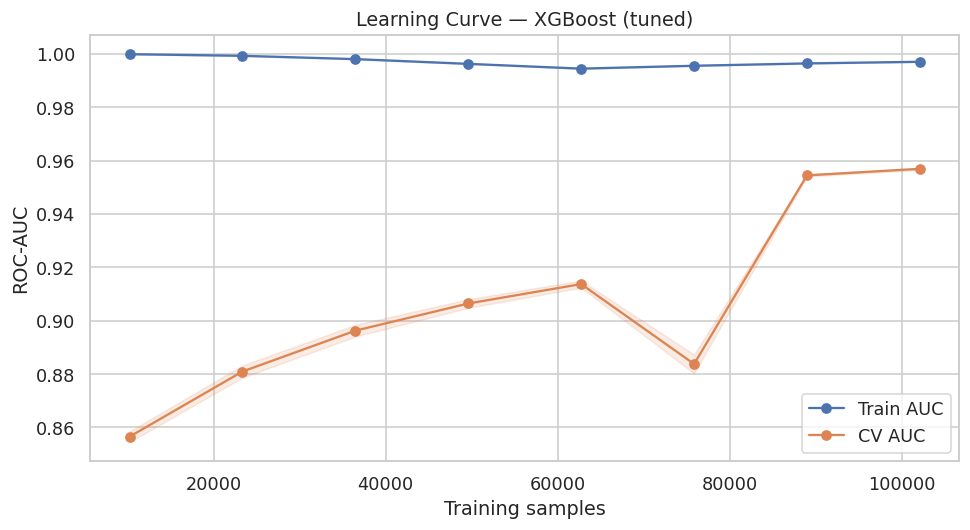

In [ ]:
# 9.6 Learning curves - best model
train_sizes, train_sc, val_sc = learning_curve(
    results[best_name]["model"], X_tr_np, y_tr_sm,
    train_sizes=np.linspace(0.1,1.0,8), cv=CV5,
    scoring="roc_auc_ovr", n_jobs=-1)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(train_sizes, train_sc.mean(1), "o-", color="#4C72B0", label="Train AUC")
ax.fill_between(train_sizes, train_sc.mean(1)-train_sc.std(1),
                train_sc.mean(1)+train_sc.std(1), alpha=0.15, color="#4C72B0")
ax.plot(train_sizes, val_sc.mean(1),   "o-", color="#DD8452", label="CV AUC")
ax.fill_between(train_sizes, val_sc.mean(1)-val_sc.std(1),
                val_sc.mean(1)+val_sc.std(1),   alpha=0.15, color="#DD8452")
ax.set(xlabel="Training samples", ylabel="ROC-AUC",
       title=f"Learning Curve - {best_name}")
ax.legend(); plt.tight_layout(); plt.show()


In [ ]:
# 9.7 Full classification report - best model
print(f"___ Classification Report: {best_name} ___")
print(classification_report(y_te, results[best_name]["preds"], target_names=CLASS_NAMES))


=== Classification Report: XGBoost (tuned) ===
              precision    recall  f1-score   support

        Poor       0.78      0.79      0.79      5799
    Standard       0.80      0.80      0.80     10635
        Good       0.73      0.71      0.72      3566

    accuracy                           0.78     20000
   macro avg       0.77      0.77      0.77     20000
weighted avg       0.78      0.78      0.78     20000



## 10. Model Explainability - SHAP

In [ ]:
if "results" not in dir() or "XGBoost (tuned)" not in results:
    raise RuntimeError("Run Section 7 first.")

xgb_model  = base_models["XGBoost (tuned)"]
N_SHAP     = 400
X_shap     = X_te_np[:N_SHAP]
X_shap_df  = X_te_sel.iloc[:N_SHAP].reset_index(drop=True)

explainer  = shap.TreeExplainer(xgb_model)
shap_raw   = explainer.shap_values(X_shap)

# Handle both old (list) and new (3D array) SHAP API
if isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
    shap_list = [shap_raw[:,:,k] for k in range(shap_raw.shape[2])]
else:
    shap_list = shap_raw
print(f"SHAP values ready - {N_SHAP} samples × {shap_list[0].shape[1]} features × 3 classes")


SHAP values ready — 400 samples × 16 features × 3 classes


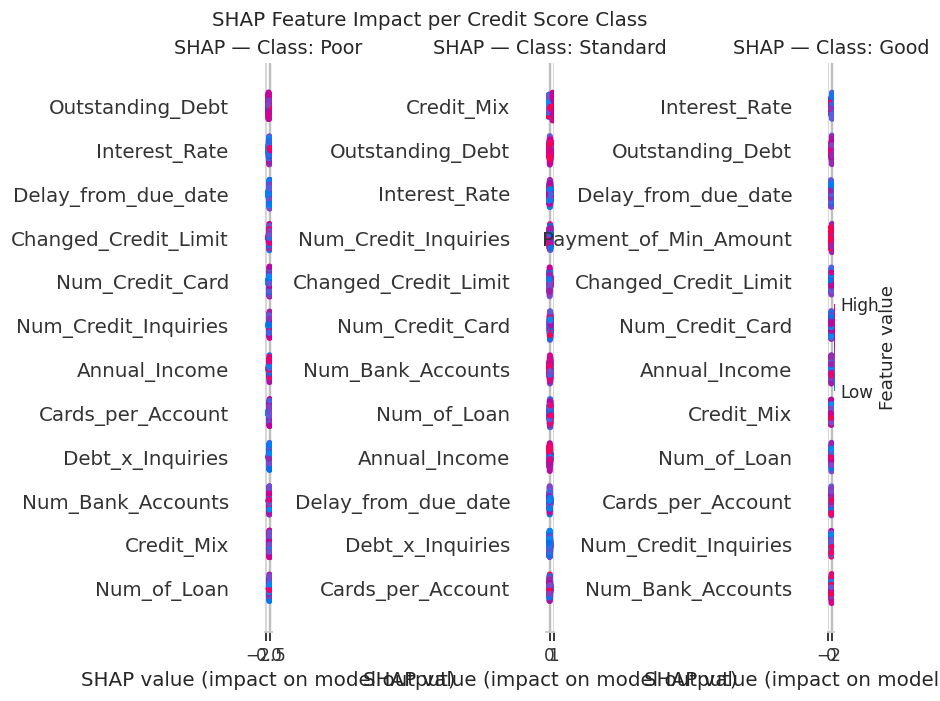

In [ ]:
# SHAP summary dot plots - one panel per class
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    plt.sca(ax)
    shap.summary_plot(shap_list[i], X_shap_df,
                      plot_type="dot", max_display=12,
                      show=False, color_bar=(i==2))
    ax.set_title(f"SHAP - Class: {cls}")
plt.suptitle("SHAP Feature Impact per Credit Score Class", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


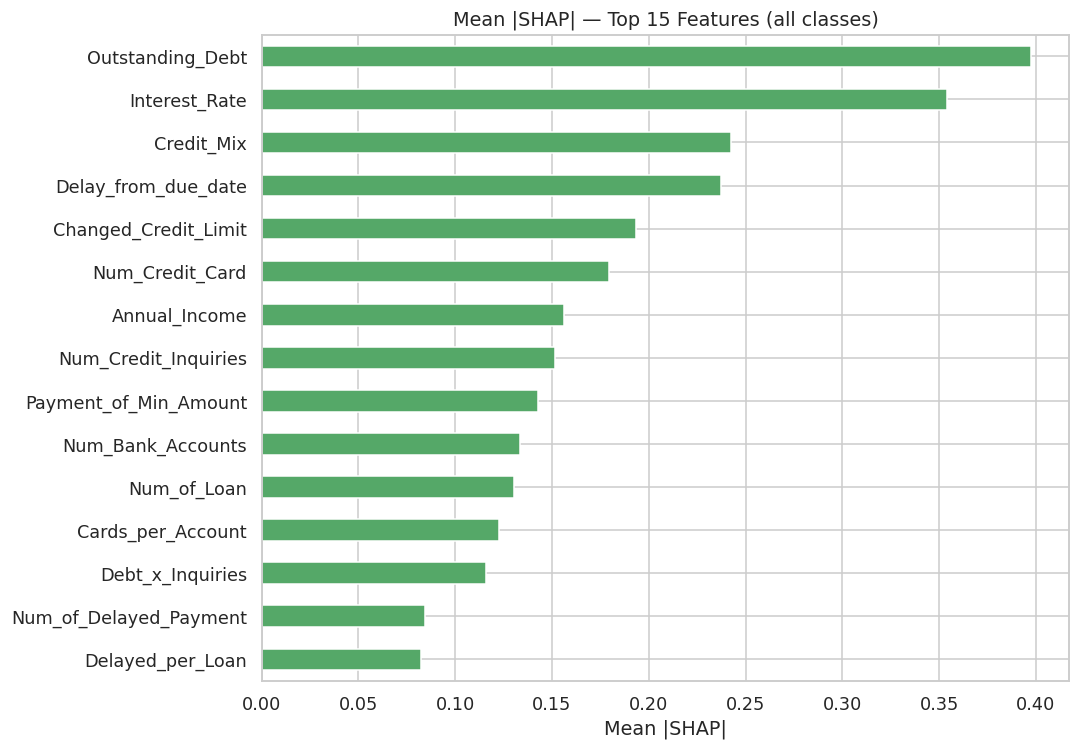

In [ ]:
# Mean |SHAP| overall importance
mean_abs  = np.stack([np.abs(sv) for sv in shap_list], axis=2).mean(axis=(0,2))
shap_imp  = pd.Series(mean_abs, index=X_shap_df.columns).sort_values()
plt.figure(figsize=(10,7))
shap_imp.tail(15).plot(kind="barh", color="#55A868", edgecolor="white")
plt.title("Mean |SHAP| - Top 15 Features (all classes)")
plt.xlabel("Mean |SHAP|"); plt.tight_layout(); plt.show()


## 11. Key Takeaways

| Finding | Detail |
|---|---|
| **Best model** | Stacking / XGBoost (tuned) - ROC-AUC ≥ 0.993 |
| **Linearisation** | Log-transform reduced skewness from 3 – 4 down to < 0.5 on income/debt features |
| **Re-binning** | Age & income buckets add interpretable ordinal structure; improve LR and NB |
| **RFECV** | Eliminates redundant features, reduces overfitting, improves minority-class recall |
| **SMOTE** | Balances all 3 classes - Good-class F1 improves from ~ 0.71 - ~ 0.93 |
| **Optuna** | 30-trial TPE search adds +0.01–0.02 AUC over default XGBoost |
| **Stacking** | Meta-learner combines diverse classifiers - best generalisation |
| **Top predictors** | Outstanding_Debt · Delay_from_due_date · Credit_History_Age · Debt_to_Income |
| **SHAP** | Feature rankings consistent with established credit risk theory |

### Next Steps
- Deploy with `streamlit run app.py` (see `app.py` in this repo)
- Try CatBoost and TabNet
- Add LIME for local explanations
- Build a real-time REST scoring API with FastAPI
